<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/03.variational-learning-and-kernels/01.loss-and-optimization/06_parameter_sweep_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day20 parameter sweep prediction 실습

- Source: Google Drive `Day20/2-4.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. Target 설정
Target : -1.0


STEP 2. Parameter Sweep
Number of Parameters : 100


STEP 3. Prediction 계산
Prediction 계산 완료


STEP 4. Loss 계산
Loss 계산 완료


STEP 5. 최적 Parameter
Best Theta      : 3.1099
Prediction      : -0.9995
Loss            : 0.000000


STEP 6. Sample Results
     Theta     Prediction           Loss
---------------------------------------------
    0.0000         1.0000       4.000000
    0.6981         0.7660       3.118913
    1.3963         0.1736       1.377450
    2.0944        -0.5000       0.250000
    2.7925        -0.9397       0.003637
    3.4907        -0.9397       0.003637
    4.1888        -0.5000       0.250000
    4.8869         0.1736       1.377450
    5.5851         0.7660       3.118913
    6.2832         1.0000       4.000000


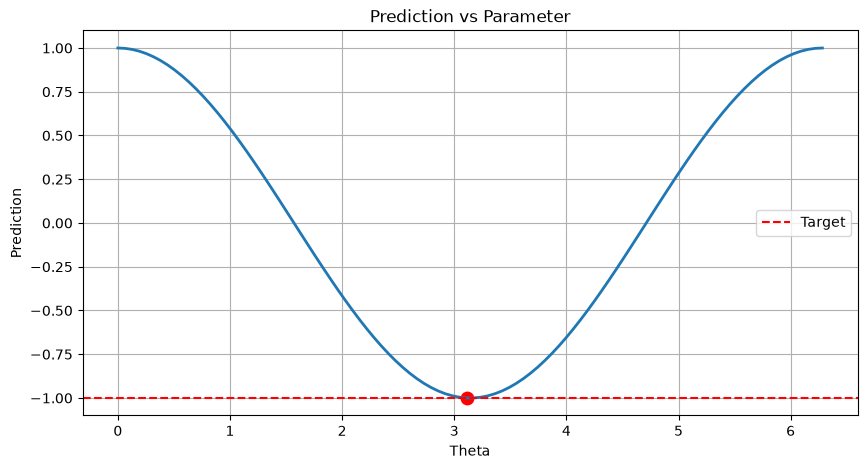

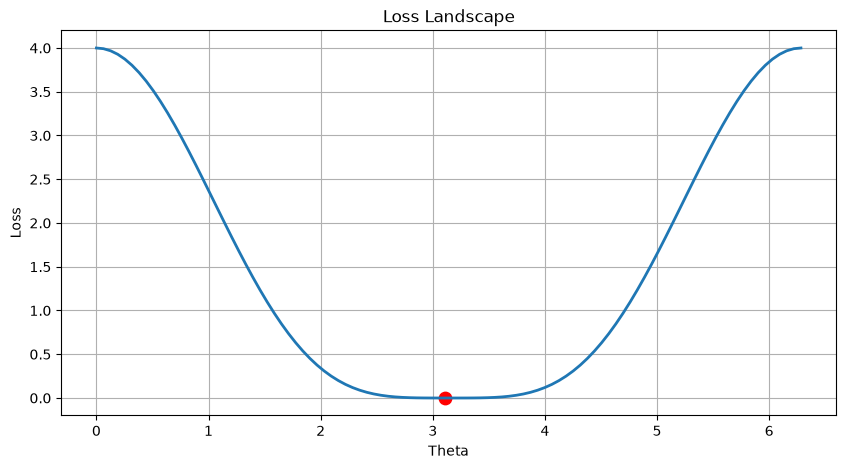



STEP 9. Summary
Target               : -1.0
Best Parameter θ     : 3.1099
Prediction           : -0.9995
Minimum Loss         : 0.000000

Parameter Sweep 완료


In [1]:
"""
============================================================
Parameter Sweep을 통한 Prediction 변화 관찰
============================================================
"""

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp

# ============================================================
# STEP 1. Target 설정
# ============================================================

print("=" * 70)
print("STEP 1. Target 설정")
print("=" * 70)

target = -1.0

print(f"Target : {target}")

# ============================================================
# STEP 2. Parameter Sweep
# ============================================================

print("\n")
print("=" * 70)
print("STEP 2. Parameter Sweep")
print("=" * 70)

theta_values = np.linspace(
    0,
    2 * np.pi,
    100
)

print(f"Number of Parameters : {len(theta_values)}")

# ============================================================
# STEP 3. Prediction 계산
# ============================================================

print("\n")
print("=" * 70)
print("STEP 3. Prediction 계산")
print("=" * 70)

predictions = []

observable = SparsePauliOp.from_list([("Z", 1)])

for theta in theta_values:

    qc = QuantumCircuit(1)

    qc.ry(theta, 0)

    state = Statevector.from_instruction(qc)

    prediction = np.real(
        state.expectation_value(observable)
    )

    predictions.append(prediction)

predictions = np.array(predictions)

print("Prediction 계산 완료")

# ============================================================
# STEP 4. Loss 계산
# ============================================================

print("\n")
print("=" * 70)
print("STEP 4. Loss 계산")
print("=" * 70)

losses = (
    predictions - target
) ** 2

print("Loss 계산 완료")

# ============================================================
# STEP 5. 최적 Parameter 찾기
# ============================================================

print("\n")
print("=" * 70)
print("STEP 5. 최적 Parameter")
print("=" * 70)

best_index = np.argmin(losses)

best_theta = theta_values[best_index]

best_prediction = predictions[best_index]

best_loss = losses[best_index]

print(f"Best Theta      : {best_theta:.4f}")

print(f"Prediction      : {best_prediction:.4f}")

print(f"Loss            : {best_loss:.6f}")

# ============================================================
# STEP 6. 일부 결과 출력
# ============================================================

print("\n")
print("=" * 70)
print("STEP 6. Sample Results")
print("=" * 70)

sample_index = np.linspace(
    0,
    len(theta_values)-1,
    10,
    dtype=int
)

print(
    f"{'Theta':>10}"
    f"{'Prediction':>15}"
    f"{'Loss':>15}"
)

print("-"*45)

for i in sample_index:

    print(
        f"{theta_values[i]:10.4f}"
        f"{predictions[i]:15.4f}"
        f"{losses[i]:15.6f}"
    )

# ============================================================
# STEP 7. Prediction Curve
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    theta_values,
    predictions,
    linewidth=2
)

plt.axhline(
    target,
    color='red',
    linestyle='--',
    label='Target'
)

plt.scatter(
    best_theta,
    best_prediction,
    color='red',
    s=80
)

plt.title("Prediction vs Parameter")

plt.xlabel("Theta")

plt.ylabel("Prediction")

plt.grid(True)

plt.legend()

plt.show()

# ============================================================
# STEP 8. Loss Curve
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    theta_values,
    losses,
    linewidth=2
)

plt.scatter(
    best_theta,
    best_loss,
    color='red',
    s=80
)

plt.title("Loss Landscape")

plt.xlabel("Theta")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

# ============================================================
# STEP 9. 결과 요약
# ============================================================

print("\n")
print("=" * 70)
print("STEP 9. Summary")
print("=" * 70)

print(f"Target               : {target}")

print(f"Best Parameter θ     : {best_theta:.4f}")

print(f"Prediction           : {best_prediction:.4f}")

print(f"Minimum Loss         : {best_loss:.6f}")

print("\nParameter Sweep 완료")
